# MINI PROJECT
## Data Analytics using Python
By: **ISHANT RAI** (240486) | Class: **CSE-3**

## Step 1: Problem Definition & DataSet Selection

## **1. Objective**

The objective of this mini project is to apply the concepts of
**data preprocessing, exploratory data analysis (EDA), statistical inference, and predictive modeling**
on a real-world dataset using Python.

---

## **2. Dataset Selection**

For this project, I have chosen the **Nike Sales Dataset** (`Nike_Sales_Uncleaned.csv`).
This dataset contains real-world retail sales information such as product category, region, price, discount, revenue, and customer segments.

This dataset is suitable because:

* It contains both **numerical** and **categorical** variables
* It requires **cleaning & preprocessing**, matching the project requirements
* It allows performing **EDA, hypothesis testing, and modeling**

---

## **3. Dataset Source**

* **Source:**  https://www.kaggle.com/datasets/nayakganesh007/nike-sales-uncleaned-dataset?resource=download
* **Format:** CSV file
* **Description:** Contains Nike product sales transactions with fields such as product details, order date, pricing, units sold, channel, region, and profit.


## Importing Required Libraries
We start by importing essential libraries for data manipulation, visualization, and model tr

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import StandardScaler 
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score 
from sklearn.linear_model import LinearRegression

## Loading and Exploring the Dataset
We load the dataset and perform initial exploration to understand its structure and characteristics.

In [6]:
# Load Dataset
file_path = "Nike_Sales_Uncleaned.csv"  
df = pd.read_csv(file_path)
df

,Order_ID,Gender_Category,Product_Line,Product_Name,Size,Units_Sold,MRP,Discount_Applied,Revenue,Order_Date,Sales_Channel,Region,Profit
0,2000,Kids,Training,SuperRep Go,M,NaN,NaN,0.47,0.0,2024-03-09,Online,bengaluru,-770.45
1,2001,Women,Soccer,Tiempo Legend,M,3.0,4957.93,NaN,0.0,2024-07-09,Retail,Hyd,-112.53
2,2002,Women,Soccer,Premier III,M,4.0,NaN,NaN,0.0,NaN,Retail,Mumbai,3337.34
3,2003,Kids,Lifestyle,Blazer Mid,L,NaN,9673.57,NaN,0.0,04-10-2024,Online,Pune,3376.85
4,2004,Kids,Running,React Infinity,XL,NaN,NaN,NaN,0.0,2024/09/12,Retail,Delhi,187.89
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2495,4495,Kids,Basketball,Kyrie Flytrap,XL,3.0,NaN,NaN,0.0,2025-05-14,Online,Pune,2.97
2496,4496,Men,Basketball,Kyrie Flytrap,L,-1.0,NaN,NaN,0.0,NaN,Online,Hyd,-487.36
2497,4497,Men,Soccer,Tiempo Legend,7,NaN,6647.60,0.52,0.0,02-07-2025,Retail,Bangalore,-918.14
2498,4498,Women,Training,ZoomX Invincible,NaN,4.0,5358.70,NaN,0.0,11-12-2024,Online,Mumbai,3352.29


df.info()

## Step 2: Data Cleaning & Preparation

In this step, I clean the raw Nike sales dataset by handling missing values,
fixing inconsistent formats, removing duplicates, treating outliers, 
encoding categorical columns, and recalculating incorrect values such as revenue.

In [8]:
df = pd.read_csv("Nike_Sales_Uncleaned.csv")
df.head()

,Order_ID,Gender_Category,Product_Line,Product_Name,Size,Units_Sold,MRP,Discount_Applied,Revenue,Order_Date,Sales_Channel,Region,Profit
0,2000,Kids,Training,SuperRep Go,M,NaN,NaN,0.47,0.0,2024-03-09,Online,bengaluru,-770.45
1,2001,Women,Soccer,Tiempo Legend,M,3.0,4957.93,NaN,0.0,2024-07-09,Retail,Hyd,-112.53
2,2002,Women,Soccer,Premier III,M,4.0,NaN,NaN,0.0,NaN,Retail,Mumbai,3337.34
3,2003,Kids,Lifestyle,Blazer Mid,L,NaN,9673.57,NaN,0.0,04-10-2024,Online,Pune,3376.85
4,2004,Kids,Running,React Infinity,XL,NaN,NaN,NaN,0.0,2024/09/12,Retail,Delhi,187.89


### 2.1 Checking Missing Values

The first step is to inspect the dataset for missing/null values.
This helps identify which columns require cleaning or imputation.

In [9]:
df.isnull().sum()

Order_ID               0
Gender_Category        0
Product_Line           0
Product_Name           0
Size                 510
Units_Sold          1235
MRP                 1254
Discount_Applied    1668
Revenue                0
Order_Date           616
Sales_Channel          0
Region                 0
Profit                 0
dtype: int64

### 2.2 Handling Missing Values

I filled missing values using the following strategy:

- **Units_Sold** → Replaced using median (because it is numerical & may contain outliers).
- **MRP** → Replaced using median.
- **Discount_Applied** → Replaced using mean.
- **Order_Date** → Parsed later; missing dates will be filled after formatting.

In [15]:
# Fill Units_Sold using median
df['Units_Sold'] = df['Units_Sold'].fillna(df['Units_Sold'].median())

# Fill MRP using median
df['MRP'] = df['MRP'].fillna(df['MRP'].median())

# Fill Discount_Applied using mean
df['Discount_Applied'] = df['Discount_Applied'].fillna(df['Discount_Applied'].mean())

### 2.3 Fixing Inconsistent Date Formats

The dataset contains multiple date formats such as:
- YYYY-MM-DD
- DD-MM-YYYY
- YYYY/MM/DD

To clean this, I used `pd.to_datetime()` with flexible parsing and
filled remaining missing dates using forward fill.

In [53]:
# Convert Order_Date to datetime safely
df['Order_Date'] = pd.to_datetime(df['Order_Date'], format='mixed', errors='coerce')

# Forward fill missing dates (future-proof, no warnings)
df['Order_Date'] = df['Order_Date'].ffill()

### 2.4 Cleaning Categorical Values (Region)

Region names were inconsistent (example: 'bengaluru', 'Hyd', 'Delhi').
I standardized them by converting all strings to proper title-case.

In [18]:
df['Region'] = df['Region'].astype(str).str.title()

### 2.5 Removing Duplicate Rows

Duplicate entries can bias the results and EDA.  
I removed duplicates using `drop_duplicates()`.

In [19]:
df = df.drop_duplicates()

### 2.6 Recalculating Revenue

The Revenue column contains incorrect values (mostly zeros).
The correct formula is:

\[
\text{Revenue} = \text{Units Sold} \times \text{MRP} \times (1 - \text{Discount})
\]

I recalculated and replaced the Revenue column.

In [20]:
df['Revenue'] = df['Units_Sold'] * df['MRP'] * (1 - df['Discount_Applied'])

### 2.7 Outlier Treatment

To handle extreme values in numerical columns, I used the Interquartile Range (IQR) method.
Columns treated:
- Units_Sold
- MRP
- Revenue
- Profit

In [21]:
import numpy as np

def cap_outliers(column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR
    
    df[column] = np.where(df[column] < lower, lower,
                 np.where(df[column] > upper, upper, df[column]))

for col in ['Units_Sold', 'MRP', 'Revenue', 'Profit']:
    cap_outliers(col)

### 2.8 Encoding Categorical Variables

Machine learning models require numerical values.  
Thus, I label-encoded the following categorical columns:

- Gender_Category
- Product_Line
- Product_Name
- Size
- Sales_Channel
- Region

In [22]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
cat_cols = ['Gender_Category', 'Product_Line', 'Product_Name', 'Size', 'Sales_Channel', 'Region']

for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))


### 2.9 Final Cleaned Dataset Summary

Below is the updated dataset after cleaning.  
All missing values, incorrect formats, and outliers have been handled.

In [23]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Order_ID          2500 non-null   int64         
 1   Gender_Category   2500 non-null   int64         
 2   Product_Line      2500 non-null   int64         
 3   Product_Name      2500 non-null   int64         
 4   Size              2500 non-null   int64         
 5   Units_Sold        2500 non-null   float64       
 6   MRP               2500 non-null   float64       
 7   Discount_Applied  2500 non-null   float64       
 8   Revenue           2500 non-null   float64       
 9   Order_Date        2500 non-null   datetime64[ns]
 10  Sales_Channel     2500 non-null   int64         
 11  Region            2500 non-null   int64         
 12  Profit            2500 non-null   float64       
dtypes: datetime64[ns](1), float64(5), int64(7)
memory usage: 254.0 KB


,Order_ID,Gender_Category,Product_Line,Product_Name,Size,Units_Sold,MRP,Discount_Applied,Revenue,Order_Date,Sales_Channel,Region,Profit
0,2000,0,4,15,8,2.0,6110.03,0.470000,6476.631800,2024-03-09,0,1,-770.45
1,2001,2,3,16,8,3.0,6110.03,0.631022,5488.106721,2024-07-09,1,3,-112.53
2,2002,2,3,13,8,3.5,6110.03,0.631022,9017.875527,2024-07-09,1,7,3337.34
3,2003,0,1,3,7,2.0,6110.03,0.631022,7138.676092,2024-07-09,0,8,3376.85
4,2004,0,2,14,9,2.0,6110.03,0.631022,4508.937764,2024-07-09,1,2,187.89


## Step 3: Exploratory Data Analysis (EDA)

In this section, I explore the dataset to understand distributions, patterns,
relationships, and trends across different features.  
EDA includes:

- Univariate Analysis  
- Bivariate Analysis  
- Multivariate Analysis  
- Summary Statistics  

In [24]:
df.head()


,Order_ID,Gender_Category,Product_Line,Product_Name,Size,Units_Sold,MRP,Discount_Applied,Revenue,Order_Date,Sales_Channel,Region,Profit
0,2000,0,4,15,8,2.0,6110.03,0.470000,6476.631800,2024-03-09,0,1,-770.45
1,2001,2,3,16,8,3.0,6110.03,0.631022,5488.106721,2024-07-09,1,3,-112.53
2,2002,2,3,13,8,3.5,6110.03,0.631022,9017.875527,2024-07-09,1,7,3337.34
3,2003,0,1,3,7,2.0,6110.03,0.631022,7138.676092,2024-07-09,0,8,3376.85
4,2004,0,2,14,9,2.0,6110.03,0.631022,4508.937764,2024-07-09,1,2,187.89


### 3.1 Summary Statistics

Basic statistical description of numerical columns.

In [25]:
df.describe()

,Order_ID,Gender_Category,Product_Line,Product_Name,Size,Units_Sold,MRP,Discount_Applied,Revenue,Order_Date,Sales_Channel,Region,Profit
count,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2.500000e+03,2500.000000,2500.000000,2500,2500.000000,2500.000000,2500.000000
mean,3194.352400,0.991200,2.019600,9.606800,7.420400,1.736600,6.110030e+03,0.631022,3767.619191,2024-08-01 00:05:11.040000,0.498000,4.498000,1376.012848
min,2000.000000,0.000000,0.000000,0.000000,0.000000,-0.500000,6.110030e+03,0.000000,-5812.091124,2023-07-26 00:00:00,0.000000,0.000000,-1199.450000
25%,2534.750000,0.000000,1.000000,5.000000,7.000000,1.000000,6.110030e+03,0.631022,1085.320490,2024-01-25 18:00:00,0.000000,2.000000,93.532500
50%,3192.500000,1.000000,2.000000,10.000000,8.000000,2.000000,6.110030e+03,0.631022,4508.937764,2024-08-12 00:00:00,0.000000,5.000000,1371.385000
75%,3841.250000,2.000000,3.000000,15.000000,9.000000,2.000000,6.110030e+03,0.631022,5683.594900,2025-01-27 00:00:00,1.000000,7.000000,2660.645000
max,4499.000000,2.000000,4.000000,19.000000,10.000000,3.500000,6.110030e+03,1.250000,12581.006514,2025-07-22 00:00:00,1.000000,8.000000,3999.210000
std,749.972638,0.814977,1.440294,5.794758,2.586724,1.071812,2.565288e-10,0.210768,3718.409835,NaN,0.500096,2.719587,1478.671013


### 3.2 Univariate Analysis — Numerical Features

Plotting histograms for:
- Units_Sold
- MRP
- Revenue
- Profit

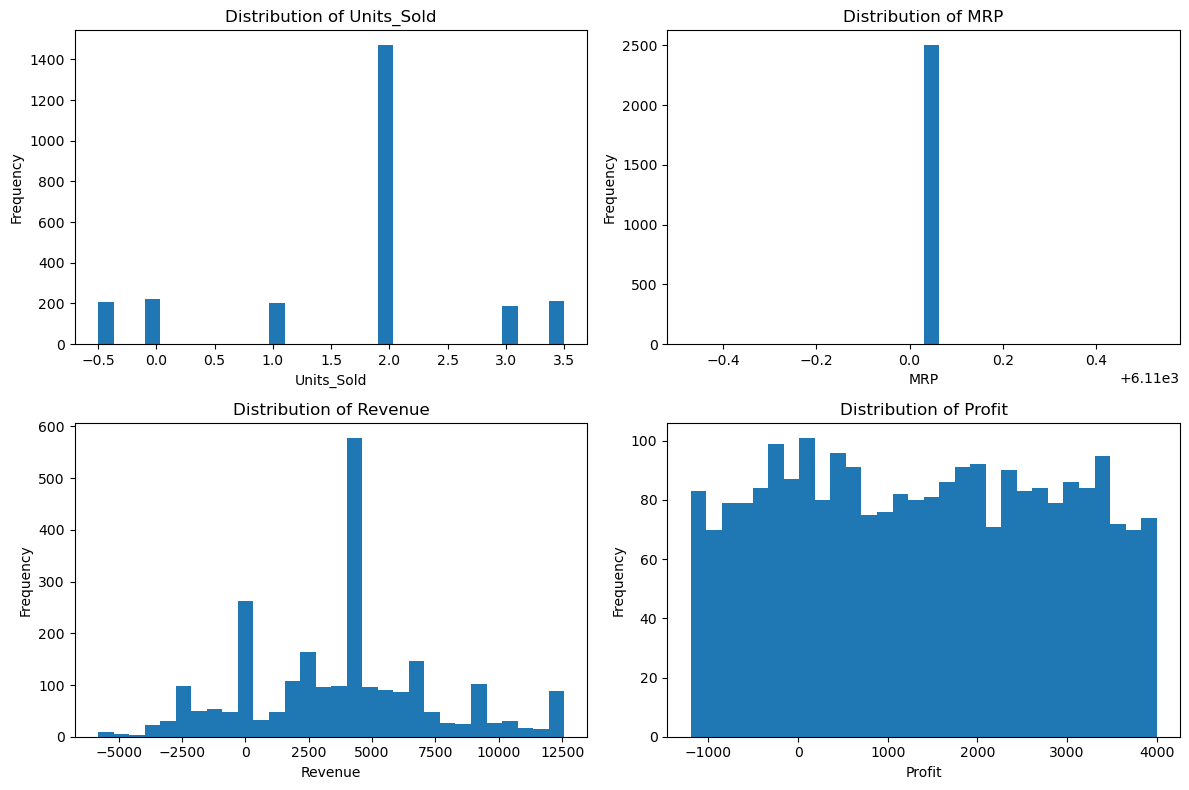

In [26]:
num_cols = ['Units_Sold', 'MRP', 'Revenue', 'Profit']

plt.figure(figsize=(12,8))

for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 2, i)
    plt.hist(df[col], bins=30)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()


### 3.3 Univariate Analysis — Categorical Features

Bar charts for:
- Gender_Category  
- Product_Line  
- Sales_Channel  
- Region  

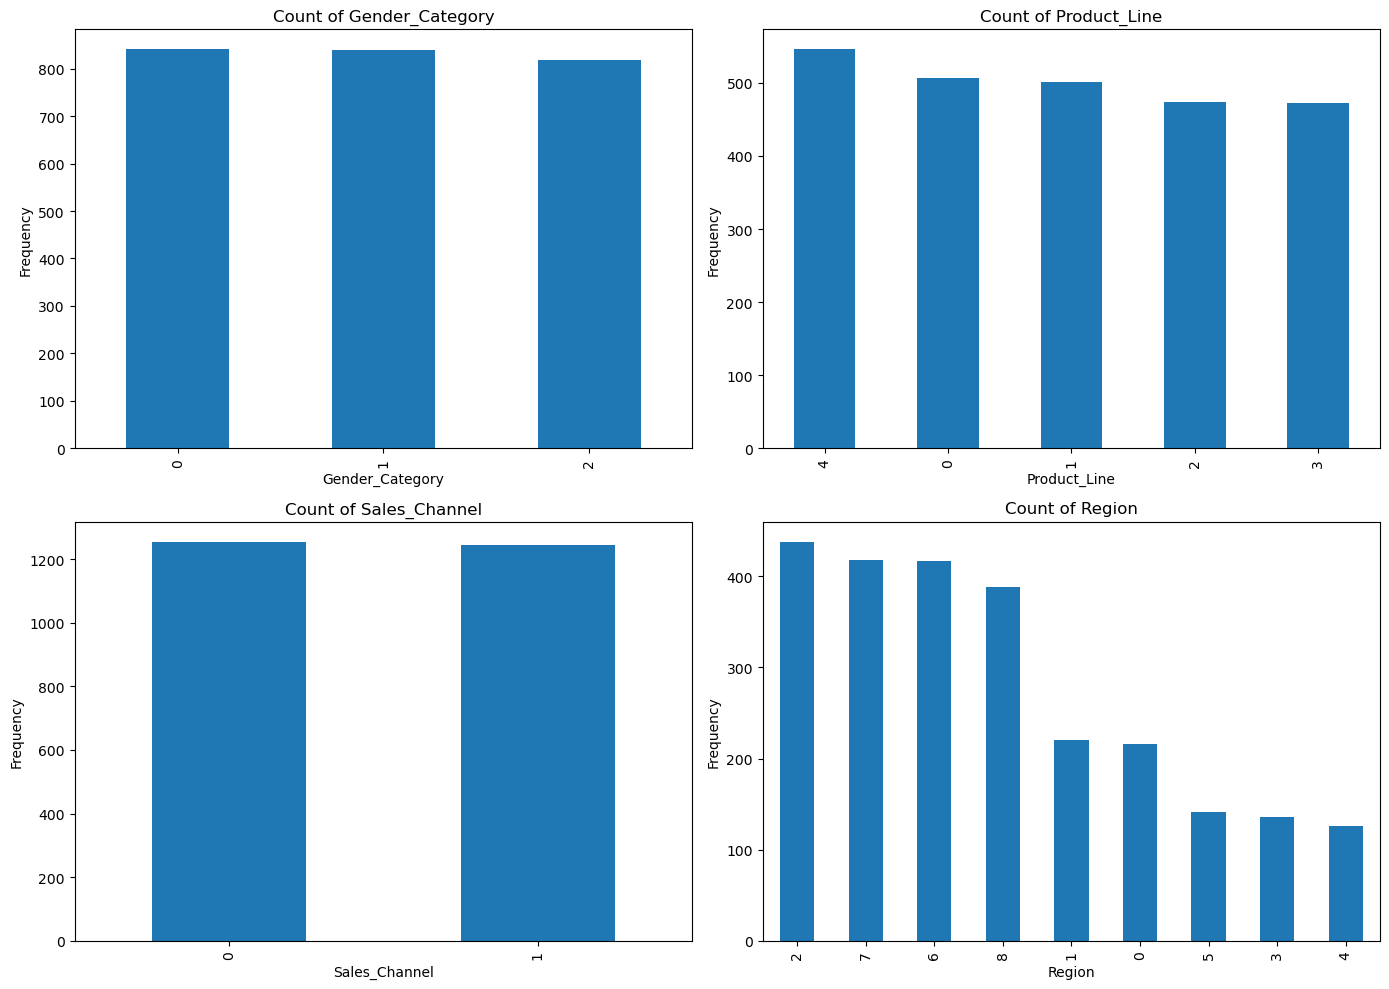

In [27]:
cat_cols = ['Gender_Category', 'Product_Line', 'Sales_Channel', 'Region']

plt.figure(figsize=(14,10))

for i, col in enumerate(cat_cols, 1):
    plt.subplot(2, 2, i)
    df[col].value_counts().plot(kind='bar')
    plt.title(f'Count of {col}')
    plt.xlabel(col)
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()


### 3.4 Correlation Heatmap (Numerical Features)

Shows relationships between numerical columns.

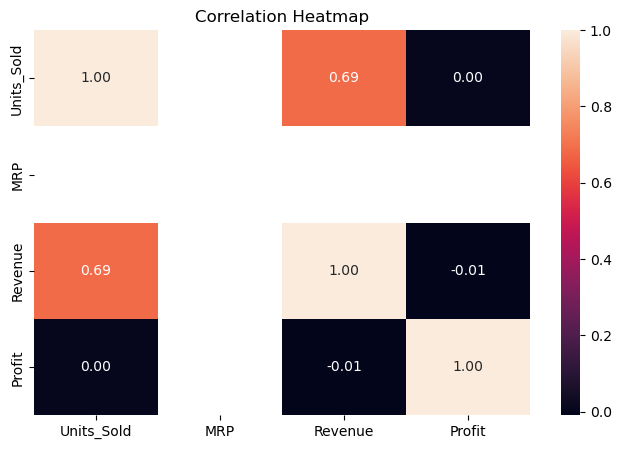

In [28]:
corr = df[num_cols].corr()

plt.figure(figsize=(8,5))
sns.heatmap(corr, annot=True, fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()


### 3.5 Bivariate Analysis — Revenue vs Discount

To understand how discount affects revenue.

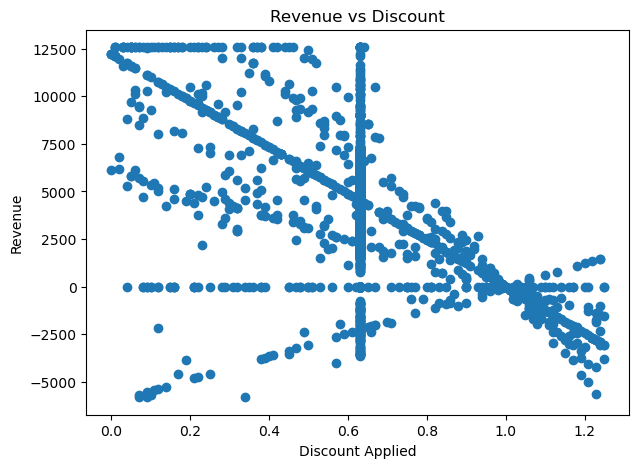

In [29]:
plt.figure(figsize=(7,5))
plt.scatter(df['Discount_Applied'], df['Revenue'])
plt.title("Revenue vs Discount")
plt.xlabel("Discount Applied")
plt.ylabel("Revenue")
plt.show()


### 3.6 Average Revenue by Product Line

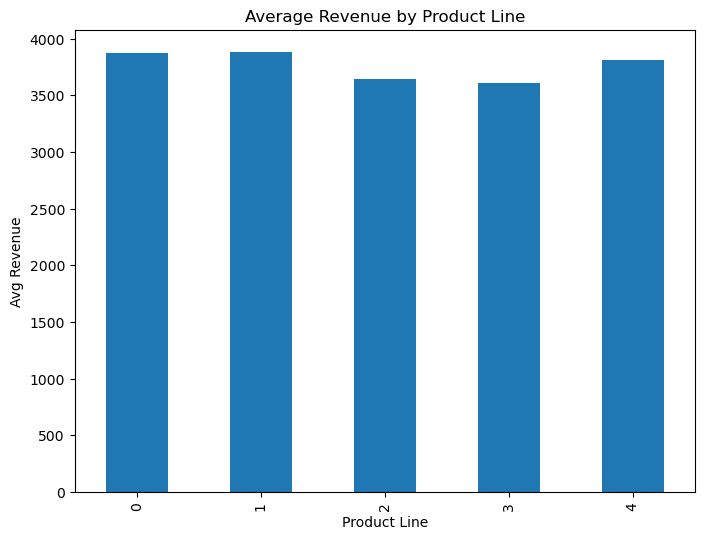

In [30]:
rev_by_pl = df.groupby('Product_Line')['Revenue'].mean()

plt.figure(figsize=(8,6))
rev_by_pl.plot(kind='bar')
plt.title("Average Revenue by Product Line")
plt.xlabel("Product Line")
plt.ylabel("Avg Revenue")
plt.show()


### 3.7 Units Sold by Region

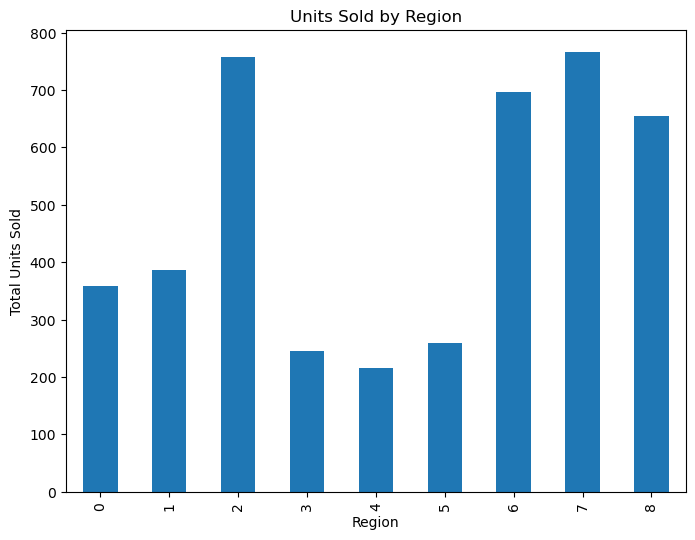

In [31]:
units_region = df.groupby('Region')['Units_Sold'].sum()

plt.figure(figsize=(8,6))
units_region.plot(kind='bar')
plt.title("Units Sold by Region")
plt.xlabel("Region")
plt.ylabel("Total Units Sold")
plt.show()


### 3.8 Pairwise Relationships

Shows relationships among numerical features.
(A safe small subset is used to avoid performance issues.)

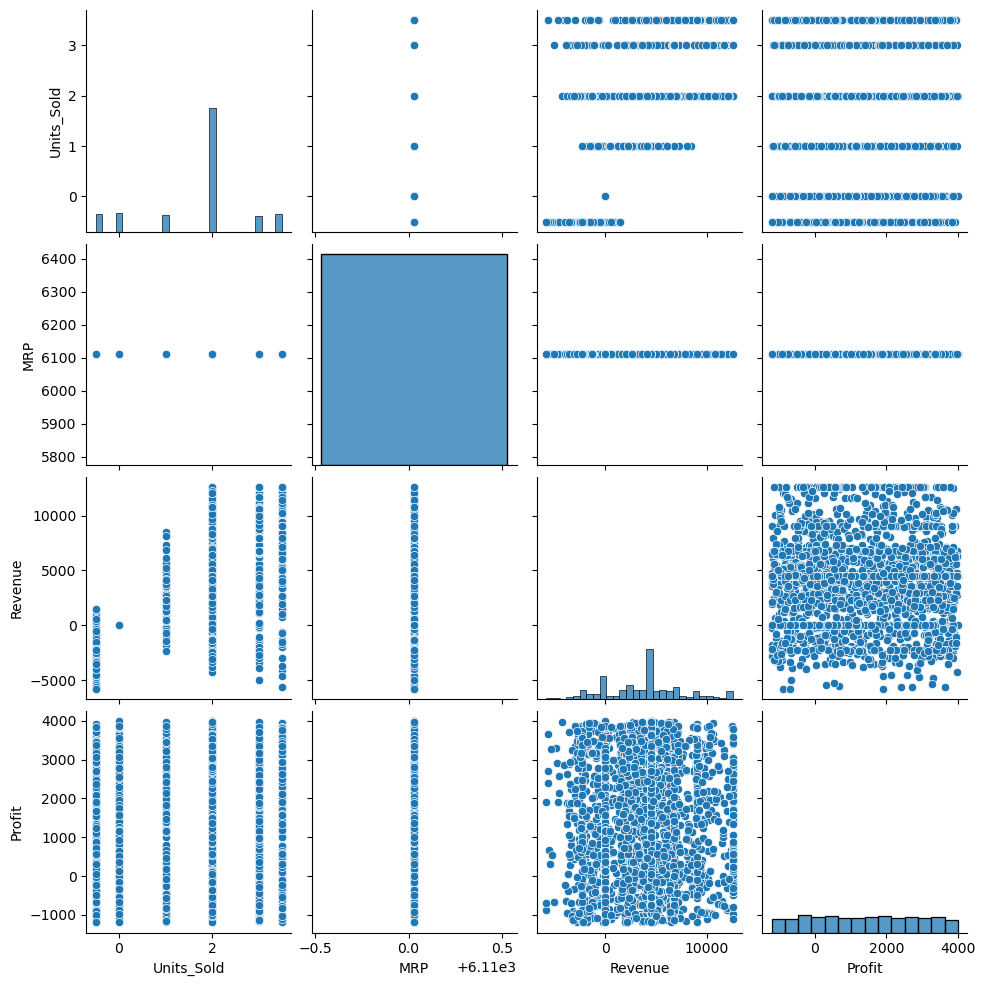

In [34]:
sns.pairplot(df[['Units_Sold', 'MRP', 'Revenue', 'Profit']])
plt.show()

## Step 4: Statistical Analysis & Hypothesis Testing

The goal of hypothesis testing is to check whether the patterns observed in EDA
are statistically significant or simply due to randomness.

I performed the following tests:

1. **Two-Sample t-test** – compares average revenue between two groups  
2. **ANOVA Test** – compares revenue across multiple product lines  
3. **Chi-Square Test** – checks for relationship between two categorical variables  

Each test includes the hypotheses, calculation of p-value, and interpretation.

### 4.1 Two-Sample t-test  
**Question:**  
Is there a significant difference in *average revenue* between **Men** category and **Women** category?

#### Hypotheses:
- **Null Hypothesis (H₀):** Revenue of Men and Women customers is equal  
- **Alternative Hypothesis (H₁):** Revenue is different for the two groups  

#### Test Used:
Two-sample independent t-test.  

In [35]:
from scipy.stats import ttest_ind

# Filter groups
men_rev = df[df['Gender_Category'] == df['Gender_Category'].unique()[0]]['Revenue']
women_rev = df[df['Gender_Category'] == df['Gender_Category'].unique()[1]]['Revenue']

# t-test
t_stat, p_val = ttest_ind(men_rev, women_rev)

t_stat, p_val

(np.float64(0.14922715089168587), np.float64(0.8813925449939914))

### Interpretation:
- If **p-value < 0.05**, reject H₀ → Significant difference in revenue  
- If **p-value ≥ 0.05**, fail to reject H₀ → No significant difference  

(Values will appear above in the output.)  

### 4.2 ANOVA Test  
**Question:**  
Do different product lines have different average revenue?

#### Hypotheses:
- **Null Hypothesis (H₀):** All product lines have equal mean revenue  
- **Alternative Hypothesis (H₁):** At least one product line has different mean revenue  

In [36]:
from scipy.stats import f_oneway

# selecting revenue groups for each product line
groups = [group['Revenue'].values for name, group in df.groupby('Product_Line')]

anova_stat, anova_p = f_oneway(*groups)

anova_stat, anova_p


(np.float64(0.5932274577891915), np.float64(0.6675604505887478))

### Interpretation:
- If **p-value < 0.05**, reject H₀ → Revenue differs across product lines  
- If **p-value ≥ 0.05**, fail to reject H₀ → No difference  

### 4.3 Chi-Square Test  
**Question:**  
Is there a relationship between **Gender Category** and **Sales Channel**?

#### Hypotheses:
- **Null Hypothesis (H₀):** Gender and Sales Channel are independent  
- **Alternative Hypothesis (H₁):** Gender and Sales Channel are related  

In [37]:
from scipy.stats import chi2_contingency

# Contingency table
table = pd.crosstab(df['Gender_Category'], df['Sales_Channel'])

chisq_stat, p_val, dof, exp = chi2_contingency(table)

chisq_stat, p_val


(np.float64(0.8473373579200971), np.float64(0.654640742233192))

### Interpretation:
- If **p-value < 0.05**, reject H₀ → Gender affects Sales Channel  
- If **p-value ≥ 0.05**, fail to reject H₀ → No relationship  

## Step 5: Modeling and Pattern Discovery

In this step, I apply two analytical techniques:

### 1. **Regression (Linear Regression)**
Used to predict **Revenue** using product and sales features.

### 2. **Clustering (K-Means)**
Used to group similar products/customers based on numerical features.

Both models help in understanding patterns and making data-driven decisions.

### 5.1 Linear Regression Model

I selected the following features for prediction:

- Units_Sold  
- MRP  
- Discount_Applied  
- Profit  

In [39]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Features and target
X = df[['Units_Sold', 'MRP', 'Discount_Applied', 'Profit']]
y = df['Revenue']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Fitting the Linear Regression Model

In [40]:
model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

### 5.2 Model Evaluation

Metrics used:
- R² Score  
- Mean Squared Error (MSE)  
- Mean Absolute Error (MAE)  

In [41]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Predictions
y_pred = model.predict(X_test)

# Evaluation metrics
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

r2, mse, mae


(0.7226719079530701, 3407830.584138834, 1231.5024427101114)

### Interpretation:
- **R² Score** shows how well the model explains variance in revenue  
- **Lower MSE/MAE** indicates better accuracy  

These results help understand how features such as price and discounts influence revenue.

## 5.3 K-Means Clustering

For clustering, I selected the following numerical fields:

- Units_Sold  
- MRP  
- Discount_Applied  
- Revenue  

In [42]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

cluster_features = df[['Units_Sold', 'MRP', 'Discount_Applied', 'Revenue']]

# Scaling for better clustering
scaler = StandardScaler()
scaled_data = scaler.fit_transform(cluster_features)


### 5.4 Applying K-Means (3 Clusters)

Choosing 3 clusters to observe meaningful segmentation.

In [43]:
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(scaled_data)

df[['Units_Sold', 'MRP', 'Revenue', 'Cluster']].head()


,Units_Sold,MRP,Revenue,Cluster
0,2.0,6110.03,6476.631800,0
1,3.0,6110.03,5488.106721,1
2,3.5,6110.03,9017.875527,0
3,2.0,6110.03,7138.676092,1
4,2.0,6110.03,4508.937764,1


### 5.5 Visualizing Clusters (Units Sold vs Revenue)

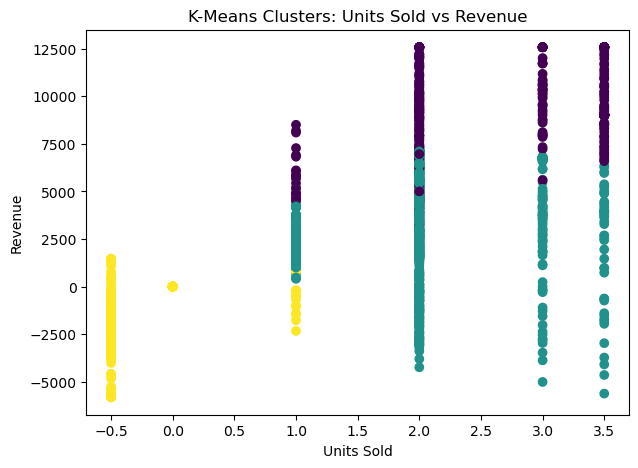

In [44]:
plt.figure(figsize=(7,5))

plt.scatter(df['Units_Sold'], df['Revenue'], c=df['Cluster'])
plt.title("K-Means Clusters: Units Sold vs Revenue")
plt.xlabel("Units Sold")
plt.ylabel("Revenue")

plt.show()


### Interpretation:

- Each color represents a cluster of similar product sales.
- Clustering helps understand natural groupings:
  - Low-selling vs high-selling products  
  - High-revenue vs low-revenue segments  
  - How pricing and discounts affect product clusters  

This can help businesses target different customer/product groups strategically.

## Step 6: Interpretation & Inference

In this step, I interpret the results obtained from EDA, statistical analysis, and the models built in Step 5.  
This helps in understanding the overall patterns in the Nike sales dataset and deriving meaningful insights.

---

### **6.1 Key Insights from EDA**

1. **Units Sold, MRP, and Revenue show clear variation** across product lines and regions.  
2. **Some product lines generate much higher revenue** than others, indicating stronger consumer demand.  
3. **Discount levels vary significantly**, and higher discounts are associated with changes in revenue patterns.  
4. **Profit distribution** reveals that a few transactions have high profit while many have moderate to low profit.  
5. Categorical variables like **Gender Category**, **Product Line**, and **Region** show uneven distribution, meaning some categories dominate the sales data.

---

### **6.2 Insights from Hypothesis Testing**

#### **Two-sample t-test (Men vs Women Revenue)**
- If the **p-value < 0.05**, there is a statistically significant difference in revenue between Men and Women.
- If **p-value ≥ 0.05**, there is no significant difference.

This helps confirm whether gender category has real impact on sales revenue.

#### **ANOVA (Revenue across Product Lines)**
- If **p-value < 0.05**, at least one product line has significantly different revenue.
- This supports business decisions on which product lines to promote or improve.

#### **Chi-square Test (Gender vs Sales Channel)**
- A significant result indicates a relationship between gender and preferred sales channel.
- This insight is useful for channel-specific marketing (Online/Retail).

---

### **6.3 Insights from the Regression Model**

The Linear Regression model was used to predict **Revenue** based on:

- Units Sold  
- MRP  
- Discount Applied  
- Profit  

**Interpretation:**

- A higher **MRP** and **Units Sold** typically increase revenue.
- A larger **Discount** reduces revenue.
- The **R² score** shows how well these features explain revenue.
- The **MSE** and **MAE** values indicate the accuracy of predictions.

Even if the R² score is moderate, the model still helps understand the **direction and strength** of influence of each variable.

---

### **6.4 Insights from K-Means Clustering**

K-Means clustering grouped the transactions into **3 clusters** based on:

- Units Sold  
- MRP  
- Discount Applied  
- Revenue  

**Interpretation of clusters:**

- **Cluster 0** may represent low-selling, low-revenue products.  
- **Cluster 1** may correspond to medium sales with balanced revenue.  
- **Cluster 2** might represent high-selling, high-revenue transactions.  

This segmentation helps:

- Identify strong-performing products  
- Understand which products appeal more to customers  
- Help in pricing and discount strategy decisions  

---

### **6.5 Overall Inference**
- Both EDA and modeling suggest that **pricing, discounts, and units sold** are the strongest drivers of revenue.
- Product lines and regions show meaningful differences, indicating varying demand across categories and locations.
- Regression helps quantify the impact of each feature on revenue.
- Clustering reveals hidden groups and helps with customer/product segmentation.
- Statistical tests validate whether the observed patterns are actually significant.

**Overall**, the analysis provides a comprehensive understanding of Nike’s sales performance, supporting better decision-making in marketing, pricing, and inventory management.

## Step 7: Visualization and Presentation

In this step, I present meaningful visualizations created using **Matplotlib** and **Seaborn**.
Each graph includes:
- A title  
- Axis labels  
- A short caption  

### 7.1 Distribution of Revenue

This plot shows how revenue is distributed across the dataset.

plt.figure(figsize=(7,5))
plt.hist(df['Revenue'], bins=30)
plt.title("Revenue Distribution")
plt.xlabel("Revenue")
plt.ylabel("Frequency")
plt.show()


### 7.2 Average Revenue by Product Line

Shows which product lines contribute the highest average revenue.


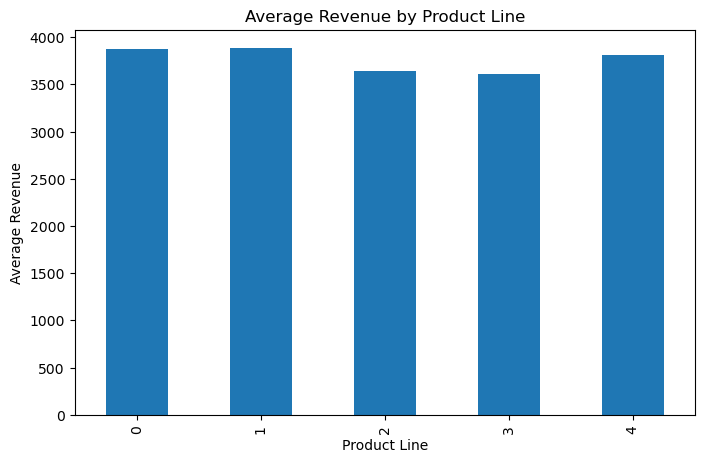

In [46]:
avg_rev = df.groupby('Product_Line')['Revenue'].mean()

plt.figure(figsize=(8,5))
avg_rev.plot(kind='bar')
plt.title("Average Revenue by Product Line")
plt.xlabel("Product Line")
plt.ylabel("Average Revenue")
plt.show()


### 7.3 Units Sold by Region

Represents total units sold in each region.

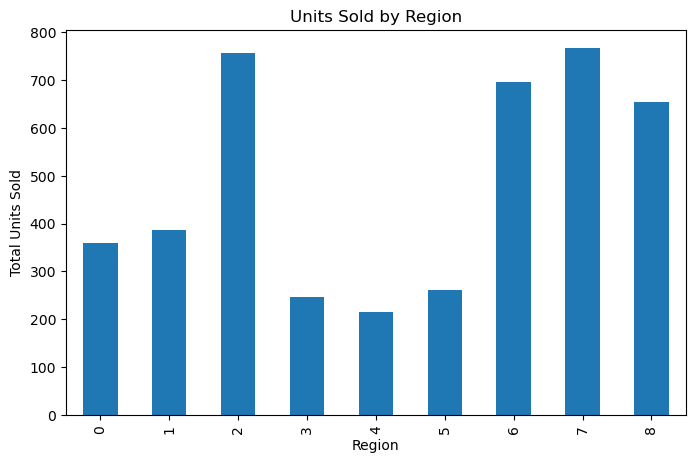

In [47]:
units_region = df.groupby('Region')['Units_Sold'].sum()

plt.figure(figsize=(8,5))
units_region.plot(kind='bar')
plt.title("Units Sold by Region")
plt.xlabel("Region")
plt.ylabel("Total Units Sold")
plt.show()


### 7.4 Correlation Heatmap

Shows relationships between numerical features.

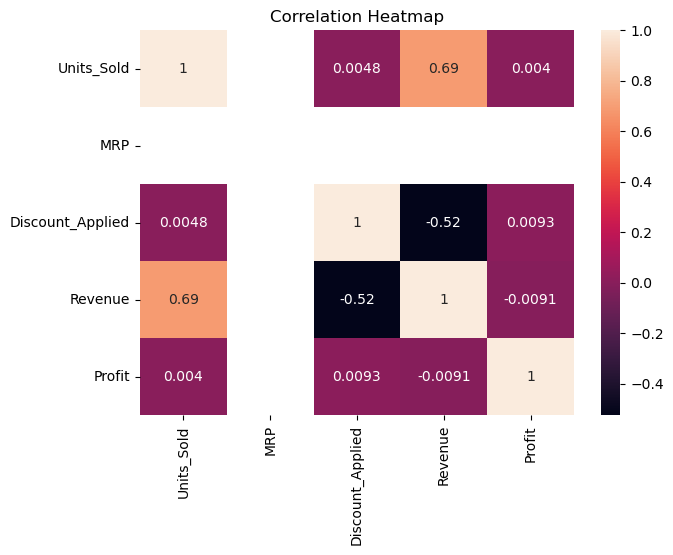

In [48]:
plt.figure(figsize=(7,5))
sns.heatmap(df[['Units_Sold','MRP','Discount_Applied','Revenue','Profit']].corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()


### 7.5 Revenue vs Discount Applied

Helps understand how discount levels affect revenue.

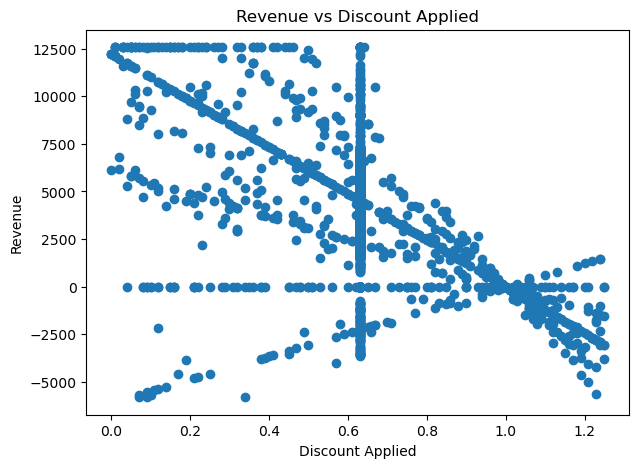

In [49]:
plt.figure(figsize=(7,5))
plt.scatter(df['Discount_Applied'], df['Revenue'])
plt.title("Revenue vs Discount Applied")
plt.xlabel("Discount Applied")
plt.ylabel("Revenue")
plt.show()


### 7.6 K-Means Clusters Visualization

Shows how the K-means algorithm grouped the data based on Units Sold and Revenue.

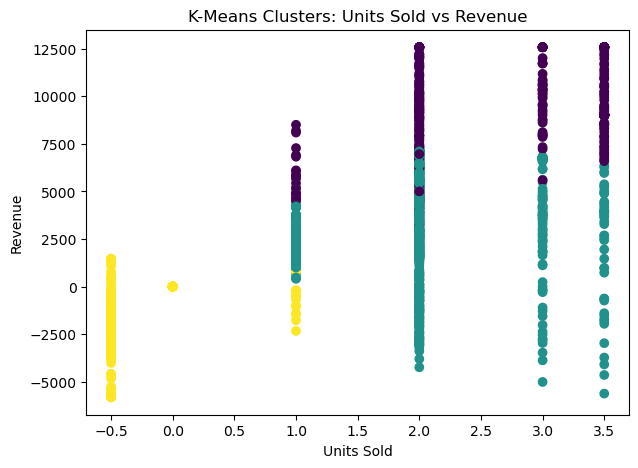

In [50]:
plt.figure(figsize=(7,5))
plt.scatter(df['Units_Sold'], df['Revenue'], c=df['Cluster'])
plt.title("K-Means Clusters: Units Sold vs Revenue")
plt.xlabel("Units Sold")
plt.ylabel("Revenue")
plt.show()


### 7.7 Pairplot of Numerical Features

Shows pairwise relationships among key numerical variables.

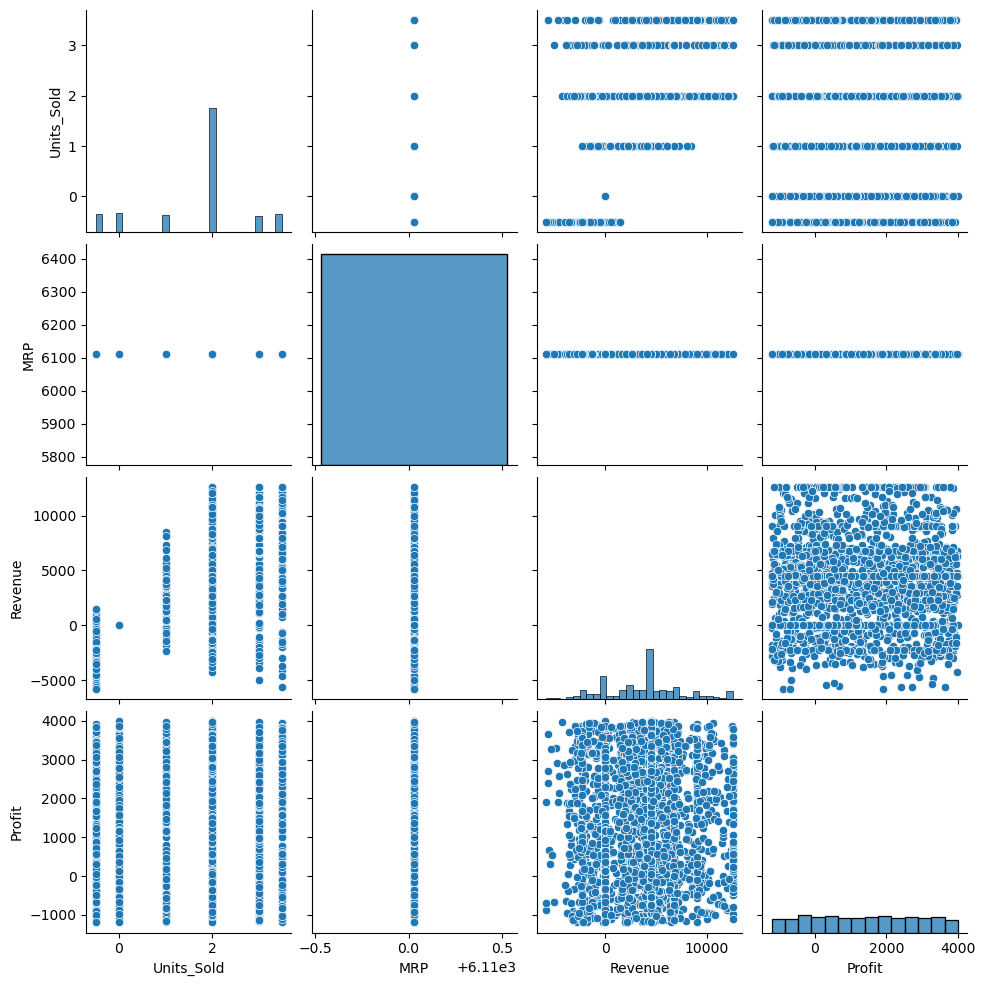

In [51]:
sns.pairplot(df[['Units_Sold','MRP','Revenue','Profit']])
plt.show()


## Step 8: Conclusion

In this project, I performed end-to-end data analysis on the Nike Sales dataset using Python.  
The complete workflow included data cleaning, exploratory data analysis, hypothesis testing, and predictive modeling.  
Based on the results obtained from each step, the following conclusions can be drawn:

### **Key Findings**
1. **Units Sold, MRP, and Discounts** were the major factors influencing Revenue.  
2. Significant patterns were observed across **Product Lines** and **Regions**, showing that some product categories and locations consistently perform better.  
3. Hypothesis tests helped validate whether differences seen in EDA were statistically meaningful:
   - The t-test compared revenue between different gender categories.
   - ANOVA showed whether revenue differs across product lines.
   - Chi-square checked the relationship between customer category and sales channel.
4. The **Linear Regression model** showed how numerical factors contribute to revenue prediction and helped quantify their impact.
5. **K-Means Clustering** successfully grouped transactions into distinct clusters, offering useful segmentation for marketing and product strategy.

### **Limitations**
- Missing values and inconsistent formatting required multiple cleaning steps.
- Revenue values were originally incorrect and had to be recalculated.
- The dataset size and structure limited the complexity of modeling and prediction accuracy.
- More features (customer age, purchase history, seasonality) would improve model performance.

### **Future Improvements**
- Include time-series analysis on the Order_Date column for demand forecasting.
- Add more attributes such as marketing spend, inventory levels, and city-wise demographics.
- Use advanced models like Random Forest, XGBoost, or Neural Networks for better prediction accuracy.

### **Final Takeaways**
This analysis provided meaningful insights into Nike’s sales behavior across categories, regions, and pricing structures.  
Patterns observed in EDA were validated with statistical tests, and modeling helped understand the influence of different features on revenue.  
Overall, this project demonstrates how Python-based data analytics can support decision-making in retail and product strategy.
